In [1]:
!pip -q install keras-tuner

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt

from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Reloading Tuner from tuner_dir/energia_cinetica/tuner0.json


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Mejores hiperparámetros:
{'num_layers': 3, 'units_0': 64, 'activation': 'relu', 'l2': 6.731750615235898e-05, 'dropout': 0.0, 'lr': 0.0013160349968348475, 'units_1': 64, 'units_2': 112}

MAE test: 0.8909885287284851
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


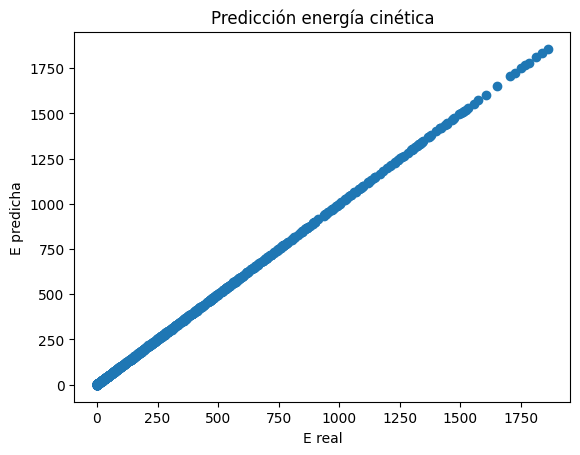

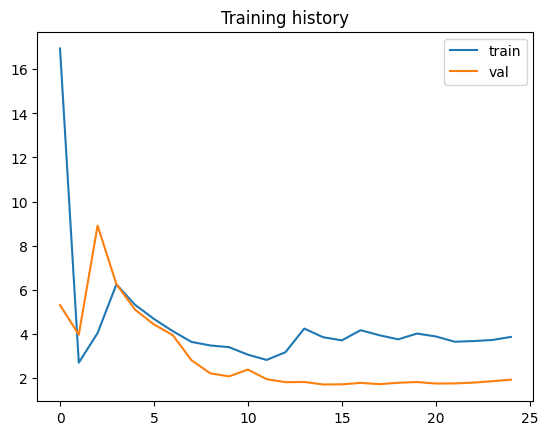

In [3]:
# ==========================================================
# ENERGÍA CINÉTICA CON REDES NEURONALES
# ==========================================================

np.random.seed(0)
tf.random.set_seed(0)

# ==========================================================
# 1. GENERAR DATOS FÍSICOS
# ==========================================================

N = 5000

m = np.random.uniform(1,10,N)
v = np.random.uniform(0,20,N)

E = 0.5*m*v**2

X = np.vstack([m,v]).T
y = E

# ==========================================================
# 2. TRAIN / VALIDATION / TEST
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=0)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,y_train,test_size=0.2,random_state=0)

# ==========================================================
# 3. NORMALIZACIÓN
# ==========================================================

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ==========================================================
# 4. MODELO CON HIPERPARAMETROS
# ==========================================================

def build_model(hp):

    model = tf.keras.Sequential()

    # número de capas
    for i in range(hp.Int("num_layers",1,3)):

        model.add(
            layers.Dense(
                units = hp.Int(f"units_{i}",16,128,step=16),
                activation = hp.Choice("activation",["relu","tanh"]),
                kernel_regularizer=tf.keras.regularizers.l2(
                    hp.Float("l2",1e-5,1e-2,sampling="log")
                )
            )
        )

        model.add(
            layers.Dropout(
                hp.Float("dropout",0.0,0.3,step=0.1)
            )
        )

    model.add(layers.Dense(1))

    lr = hp.Float("lr",1e-4,1e-2,sampling="log")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
        metrics=["mae"]
    )

    return model


# ==========================================================
# 5. HIPERPARAMETER SEARCH
# ==========================================================

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=15,
    executions_per_trial=1,
    directory="tuner_dir",
    project_name="energia_cinetica"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

tuner.search(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=100,
    callbacks=[early_stop],
    verbose=0
)

best_model = tuner.get_best_models(1)[0]

print("\nMejores hiperparámetros:")
print(tuner.get_best_hyperparameters(1)[0].values)


# ==========================================================
# 6. ENTRENAMIENTO FINAL
# ==========================================================

history = best_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=200,
    callbacks=[early_stop],
    verbose=0
)

# ==========================================================
# 7. EVALUACIÓN
# ==========================================================

loss, mae = best_model.evaluate(X_test,y_test,verbose=0)

print("\nMAE test:",mae)

y_pred = best_model.predict(X_test)

plt.figure()
plt.scatter(y_test,y_pred)
plt.xlabel("E real")
plt.ylabel("E predicha")
plt.title("Predicción energía cinética")
plt.show()

# ==========================================================
# 8. CURVA DE ENTRENAMIENTO
# ==========================================================

plt.figure()
plt.plot(history.history["loss"],label="train")
plt.plot(history.history["val_loss"],label="val")
plt.legend()
plt.title("Training history")
plt.show()

Reloading Tuner from tuner_dir/movimiento_acelerado/tuner0.json


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Mejores hiperparámetros encontrados:
{'num_layers': 1, 'units_0': 112, 'activation': 'relu', 'l2': 2.442581719937833e-05, 'dropout': 0.1, 'lr': 0.008243668311854, 'units_1': 64, 'units_2': 96}

MAE en test: 0.4424617886543274
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


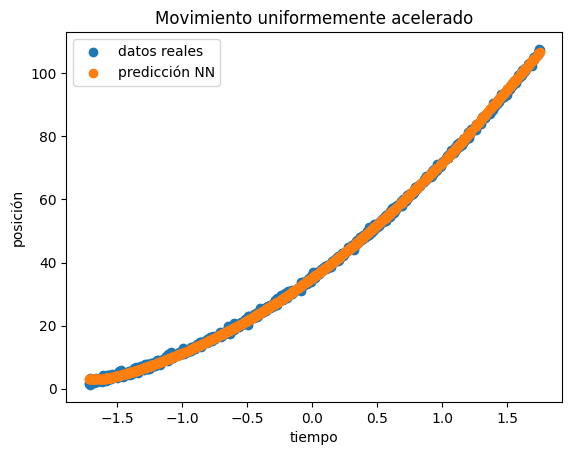

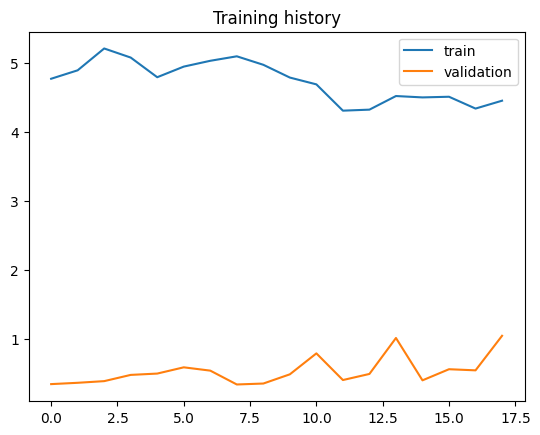

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


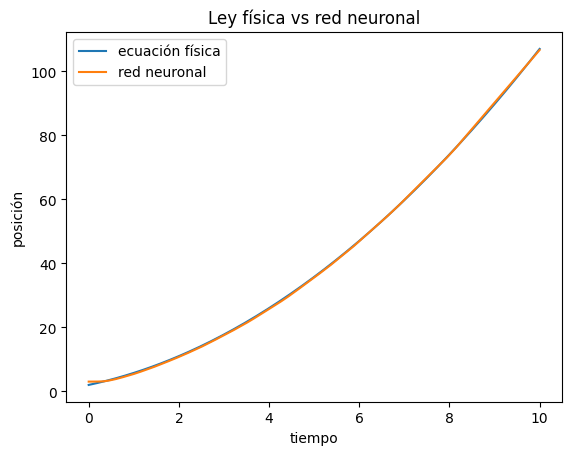

In [4]:
# ==========================================================
# MOVIMIENTO UNIFORMEMENTE ACELERADO CON RED NEURONAL
# ==========================================================

np.random.seed(42)
tf.random.set_seed(42)

# ==========================================================
# 1. GENERACIÓN DE DATOS FÍSICOS
# x = x0 + v0 t + 1/2 a t^2
# ==========================================================

N = 5000

t = np.random.uniform(0,10,N)

x0 = 2
v0 = 3
a = 1.5

x = x0 + v0*t + 0.5*a*t**2

# ruido experimental
x = x + np.random.normal(0,0.5,N)

X = t.reshape(-1,1)
y = x

# ==========================================================
# 2. TRAIN / VALIDATION / TEST
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=0)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,y_train,test_size=0.2,random_state=0)

# ==========================================================
# 3. NORMALIZACIÓN
# ==========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ==========================================================
# 4. MODELO CON HIPERPARÁMETROS
# ==========================================================

def build_model(hp):

    model = tf.keras.Sequential()

    # número de capas ocultas
    for i in range(hp.Int("num_layers",1,3)):

        model.add(
            layers.Dense(
                units = hp.Int(f"units_{i}",16,128,step=16),
                activation = hp.Choice("activation",["relu","tanh"]),
                kernel_regularizer=tf.keras.regularizers.l2(
                    hp.Float("l2",1e-5,1e-2,sampling="log")
                )
            )
        )

        model.add(
            layers.Dropout(
                hp.Float("dropout",0.0,0.3,step=0.1)
            )
        )

    model.add(layers.Dense(1))

    lr = hp.Float("lr",1e-4,1e-2,sampling="log")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
        metrics=["mae"]
    )

    return model

# ==========================================================
# 5. HIPERPARAMETER SEARCH
# ==========================================================

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=15,
    executions_per_trial=1,
    directory="tuner_dir",
    project_name="movimiento_acelerado"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

tuner.search(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=100,
    callbacks=[early_stop],
    verbose=0
)

best_model = tuner.get_best_models(1)[0]

print("\nMejores hiperparámetros encontrados:")
print(tuner.get_best_hyperparameters(1)[0].values)

# ==========================================================
# 6. ENTRENAMIENTO FINAL
# ==========================================================

history = best_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=200,
    callbacks=[early_stop],
    verbose=0
)

# ==========================================================
# 7. EVALUACIÓN
# ==========================================================

loss, mae = best_model.evaluate(X_test,y_test,verbose=0)

print("\nMAE en test:",mae)

y_pred = best_model.predict(X_test)

# ==========================================================
# 8. COMPARACIÓN FÍSICA
# ==========================================================

plt.figure()
plt.scatter(X_test,y_test,label="datos reales")
plt.scatter(X_test,y_pred,label="predicción NN")
plt.xlabel("tiempo")
plt.ylabel("posición")
plt.legend()
plt.title("Movimiento uniformemente acelerado")
plt.show()

# ==========================================================
# 9. CURVAS DE ENTRENAMIENTO
# ==========================================================

plt.figure()
plt.plot(history.history["loss"],label="train")
plt.plot(history.history["val_loss"],label="validation")
plt.legend()
plt.title("Training history")
plt.show()

# ==========================================================
# 10. COMPARACIÓN CON LA ECUACIÓN FÍSICA
# ==========================================================

t_line = np.linspace(0,10,200)

x_real = x0 + v0*t_line + 0.5*a*t_line**2
x_nn = best_model.predict(scaler.transform(t_line.reshape(-1,1)))

plt.figure()
plt.plot(t_line,x_real,label="ecuación física")
plt.plot(t_line,x_nn,label="red neuronal")
plt.legend()
plt.xlabel("tiempo")
plt.ylabel("posición")
plt.title("Ley física vs red neuronal")
plt.show()

Reloading Tuner from tuner_dir/oscilador_armonico/tuner0.json


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Mejores hiperparámetros encontrados:
{'num_layers': 3, 'units_0': 160, 'activation': 'relu', 'l2': 8.536048623556879e-05, 'dropout': 0.0, 'lr': 0.0009016928015042564, 'units_1': 32, 'units_2': 32}

MAE en test: 0.09440550208091736
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


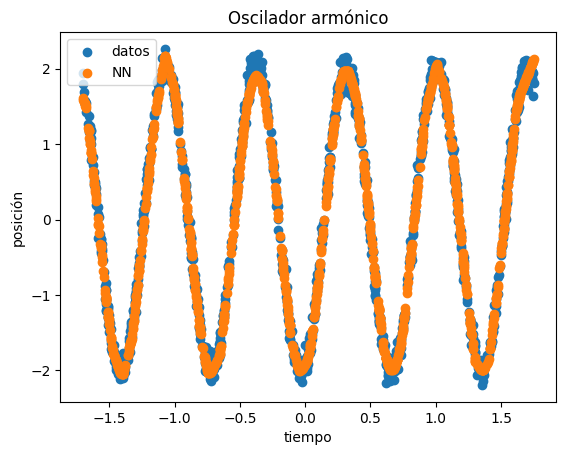

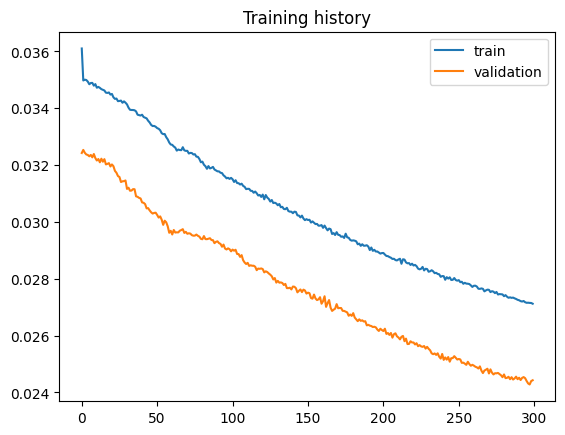

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


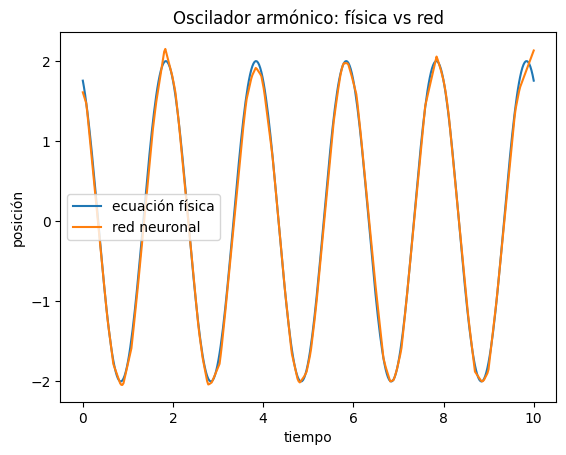

In [5]:
# ==========================================================
# OSCILADOR ARMÓNICO SIMPLE CON RED NEURONAL
# ==========================================================
np.random.seed(42)
tf.random.set_seed(42)

# ==========================================================
# 1. GENERACIÓN DE DATOS FÍSICOS
# x(t) = A cos(wt + phi)
# ==========================================================

N = 6000

t = np.random.uniform(0,10,N)

A = 2
w = 2*np.pi*0.5
phi = 0.5

x = A*np.cos(w*t + phi)

# ruido experimental
x = x + np.random.normal(0,0.1,N)

X = t.reshape(-1,1)
y = x

# ==========================================================
# 2. TRAIN / VALIDATION / TEST
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=0)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,y_train,test_size=0.2,random_state=0)

# ==========================================================
# 3. NORMALIZACIÓN
# ==========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ==========================================================
# 4. MODELO CON HIPERPARÁMETROS
# ==========================================================

def build_model(hp):

    model = tf.keras.Sequential()

    for i in range(hp.Int("num_layers",1,3)):

        model.add(
            layers.Dense(
                units = hp.Int(f"units_{i}",32,256,step=32),
                activation = hp.Choice("activation",["tanh","relu"]),
                kernel_regularizer=tf.keras.regularizers.l2(
                    hp.Float("l2",1e-6,1e-2,sampling="log")
                )
            )
        )

        model.add(
            layers.Dropout(
                hp.Float("dropout",0.0,0.4,step=0.1)
            )
        )

    model.add(layers.Dense(1))

    lr = hp.Float("lr",1e-4,1e-2,sampling="log")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
        metrics=["mae"]
    )

    return model

# ==========================================================
# 5. HIPERPARAMETER SEARCH
# ==========================================================

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=20,
    executions_per_trial=1,
    directory="tuner_dir",
    project_name="oscilador_armonico"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

tuner.search(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=150,
    callbacks=[early_stop],
    verbose=0
)

best_model = tuner.get_best_models(1)[0]

print("\nMejores hiperparámetros encontrados:")
print(tuner.get_best_hyperparameters(1)[0].values)

# ==========================================================
# 6. ENTRENAMIENTO FINAL
# ==========================================================

history = best_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=300,
    callbacks=[early_stop],
    verbose=0
)

# ==========================================================
# 7. EVALUACIÓN
# ==========================================================

loss, mae = best_model.evaluate(X_test,y_test,verbose=0)

print("\nMAE en test:",mae)

y_pred = best_model.predict(X_test)

# ==========================================================
# 8. COMPARACIÓN DATOS VS RED
# ==========================================================

plt.figure()
plt.scatter(X_test,y_test,label="datos")
plt.scatter(X_test,y_pred,label="NN")
plt.xlabel("tiempo")
plt.ylabel("posición")
plt.legend()
plt.title("Oscilador armónico")
plt.show()

# ==========================================================
# 9. HISTORIA DE ENTRENAMIENTO
# ==========================================================

plt.figure()
plt.plot(history.history["loss"],label="train")
plt.plot(history.history["val_loss"],label="validation")
plt.legend()
plt.title("Training history")
plt.show()

# ==========================================================
# 10. COMPARACIÓN CON LA SOLUCIÓN FÍSICA
# ==========================================================

t_line = np.linspace(0,10,400)

x_real = A*np.cos(w*t_line + phi)
x_nn = best_model.predict(scaler.transform(t_line.reshape(-1,1)))

plt.figure()
plt.plot(t_line,x_real,label="ecuación física")
plt.plot(t_line,x_nn,label="red neuronal")
plt.legend()
plt.xlabel("tiempo")
plt.ylabel("posición")
plt.title("Oscilador armónico: física vs red")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Mejores hiperparámetros:
{'num_layers': 2, 'units_0': 80, 'activation': 'relu', 'l2': 1.780413250137939e-05, 'dropout': 0.0, 'lr': 0.00039352681125392927, 'units_1': 32, 'units_2': 64}

MAE test: 0.3953973650932312
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


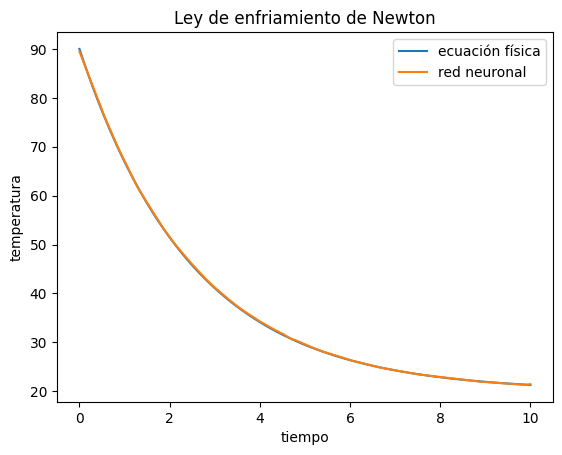

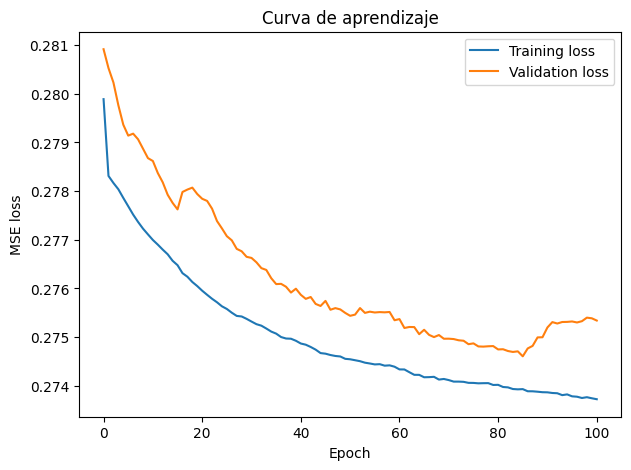

In [6]:
# ==========================================================
# LEY DE ENFRIAMIENTO DE NEWTON CON RED NEURONAL
# ==========================================================
np.random.seed(42)
tf.random.set_seed(42)

# ==========================================================
# 1. DATOS FÍSICOS
# T(t) = Tamb + (T0 - Tamb) exp(-kt)
# ==========================================================

N = 6000

t = np.random.uniform(0,10,N)

Tamb = 20
T0 = 90
k = 0.4

T = Tamb + (T0-Tamb)*np.exp(-k*t)

# ruido experimental
T = T + np.random.normal(0,0.5,N)

X = t.reshape(-1,1)
y = T

# ==========================================================
# 2. SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=0)

# ==========================================================
# 3. NORMALIZACIÓN
# ==========================================================

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ==========================================================
# 4. MODELO
# ==========================================================

def build_model(hp):

    model = tf.keras.Sequential()

    for i in range(hp.Int("num_layers",1,3)):

        model.add(
            layers.Dense(
                units = hp.Int(f"units_{i}",16,128,step=16),
                activation = hp.Choice("activation",["relu","tanh"]),
                kernel_regularizer=tf.keras.regularizers.l2(
                    hp.Float("l2",1e-6,1e-2,sampling="log")
                )
            )
        )

        model.add(
            layers.Dropout(
                hp.Float("dropout",0.0,0.4,step=0.1)
            )
        )

    model.add(layers.Dense(1))

    lr = hp.Float("lr",1e-4,1e-2,sampling="log")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
        metrics=["mae"]
    )

    return model

# ==========================================================
# 5. BUSQUEDA DE HIPERPARÁMETROS
# ==========================================================

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=20,
    directory="tuner_dir",
    project_name="enfriamiento"
)

early_stop = EarlyStopping(monitor="val_loss",patience=15,restore_best_weights=True)

tuner.search(
    X_train,y_train,
    validation_data=(X_val,y_val),
    epochs=150,
    callbacks=[early_stop],
    verbose=0
)

best_model = tuner.get_best_models(1)[0]

print("Mejores hiperparámetros:")
print(tuner.get_best_hyperparameters(1)[0].values)

# ==========================================================
# 6. ENTRENAMIENTO FINAL
# ==========================================================

history = best_model.fit(
    X_train,y_train,
    validation_data=(X_val,y_val),
    epochs=300,
    callbacks=[early_stop],
    verbose=0
)

# ==========================================================
# 7. EVALUACIÓN
# ==========================================================

loss,mae = best_model.evaluate(X_test,y_test,verbose=0)
print("\nMAE test:",mae)

# ==========================================================
# 8. COMPARACIÓN CON LA LEY FÍSICA
# ==========================================================

t_line = np.linspace(0,10,300)

T_real = Tamb + (T0-Tamb)*np.exp(-k*t_line)
T_nn = best_model.predict(scaler.transform(t_line.reshape(-1,1)))

plt.figure()
plt.plot(t_line,T_real,label="ecuación física")
plt.plot(t_line,T_nn,label="red neuronal")
plt.xlabel("tiempo")
plt.ylabel("temperatura")
plt.legend()
plt.title("Ley de enfriamiento de Newton")
plt.show()

# ==========================================================
# 9. CURVA DE APRENDIZAJE
# ==========================================================

plt.figure(figsize=(7,5))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")

plt.title("Curva de aprendizaje")

plt.legend()

plt.show()

Trial 20 Complete [00h 01m 35s]
val_loss: 13.795051574707031

Best val_loss So Far: 0.3547314405441284
Total elapsed time: 00h 23m 25s

Mejores hiperparámetros encontrados:
{'num_layers': 3, 'units_0': 96, 'activation': 'relu', 'l2': 2.34288249786853e-06, 'dropout': 0.0, 'lr': 0.002676579420098818, 'units_1': 256, 'units_2': 96}
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5403 - mae: 0.3050 - val_loss: 0.6337 - val_mae: 0.3191
Epoch 2/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1374 - mae: 0.3521 - val_loss: 0.6932 - val_mae: 0.2879
Epoch 3/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4074 - mae: 0.3179 - val_loss: 0.2333 - val_mae: 0.2169
Epoch 4/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2436 - mae: 0.2451 - val_loss: 0.5181 - val_mae: 0.2426
Epoch 5/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9533 - mae: 0.3557 - val_loss: 0.3517 - val_mae: 0.2743
Epoch 6/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3802 - mae: 0.2872 - val_loss: 1.1727 - val_mae: 0.2458
Epoch 7/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.3464 - mae: 0.3583 - val_loss: 2.1249 - val_mae: 0.4307
Epoch 8/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0171 - mae: 0.4390 - val_loss: 1.6151 - val_mae: 0.4065
Epoch 9/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss:

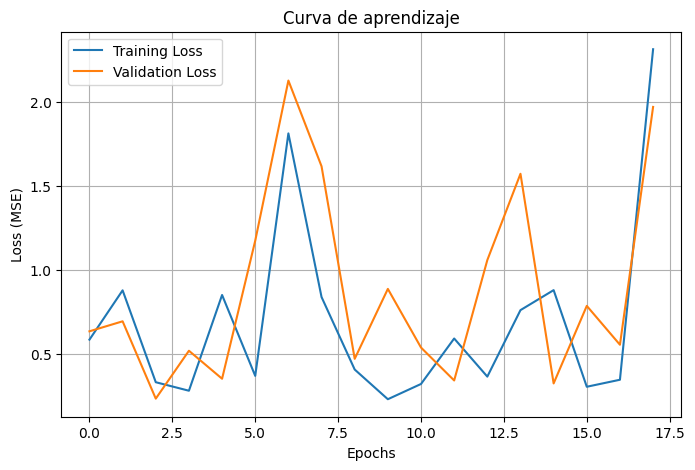

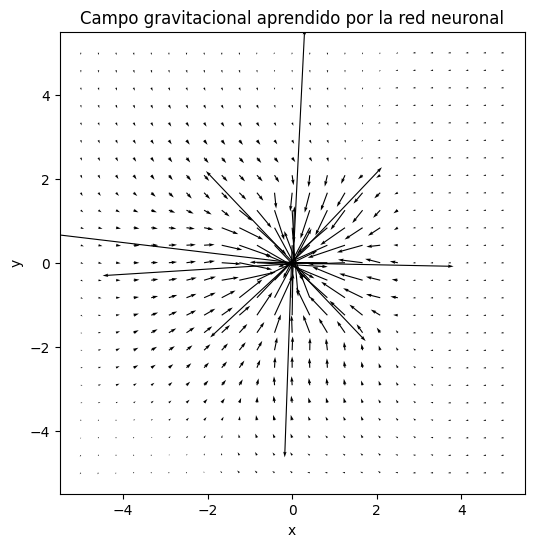

In [7]:
# ==========================================================
# CAMPO GRAVITACIONAL CON RED NEURONAL
# ==========================================================

np.random.seed(42)
tf.random.set_seed(42)

# ==========================================================
# 1. DATOS FÍSICOS
# g = GM/r^2
# ==========================================================

N = 8000

x = np.random.uniform(-5,5,N)
y = np.random.uniform(-5,5,N)

G = 1
M = 10

r = np.sqrt(x**2 + y**2) + 0.1

gx = -G*M*x/(r**3)
gy = -G*M*y/(r**3)

# ruido experimental
gx += np.random.normal(0,0.01,N)
gy += np.random.normal(0,0.01,N)

X = np.vstack([x,y]).T
Y = np.vstack([gx,gy]).T

# ==========================================================
# 2. SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,Y,test_size=0.2,random_state=0
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,y_train,test_size=0.2,random_state=0
)

# ==========================================================
# 3. NORMALIZACIÓN
# ==========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ==========================================================
# 4. MODELO CON HIPERPARÁMETROS
# ==========================================================

def build_model(hp):

    model = tf.keras.Sequential()

    for i in range(hp.Int("num_layers",1,3)):

        model.add(
            layers.Dense(
                units = hp.Int(f"units_{i}",32,256,step=32),
                activation = hp.Choice("activation",["relu","tanh"]),
                kernel_regularizer=tf.keras.regularizers.l2(
                    hp.Float("l2",1e-6,1e-2,sampling="log")
                )
            )
        )

        model.add(
            layers.Dropout(
                hp.Float("dropout",0.0,0.3,step=0.1)
            )
        )

    model.add(layers.Dense(2))

    lr = hp.Float("lr",1e-4,1e-2,sampling="log")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
        metrics=["mae"]
    )

    return model

# ==========================================================
# 5. BÚSQUEDA DE HIPERPARÁMETROS
# ==========================================================

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=20,
    directory="tuner_dir",
    project_name="campo_gravitacional"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

tuner.search(
    X_train,y_train,
    validation_data=(X_val,y_val),
    epochs=150,
    callbacks=[early_stop],
    verbose=1
)

best_model = tuner.get_best_models(1)[0]

print("\nMejores hiperparámetros encontrados:")
print(tuner.get_best_hyperparameters(1)[0].values)

# ==========================================================
# 6. ENTRENAMIENTO FINAL
# ==========================================================

history = best_model.fit(
    X_train,y_train,
    validation_data=(X_val,y_val),
    epochs=300,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================================
# 7. CURVA DE APRENDIZAJE
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Curva de aprendizaje")
plt.legend()
plt.grid()

plt.show()

# ==========================================================
# 8. CAMPO APRENDIDO
# ==========================================================

grid = np.linspace(-5,5,25)
Xg,Yg = np.meshgrid(grid,grid)

points = np.vstack([Xg.ravel(),Yg.ravel()]).T

pred = best_model.predict(scaler.transform(points), verbose=0)

gx_pred = pred[:,0].reshape(Xg.shape)
gy_pred = pred[:,1].reshape(Yg.shape)

plt.figure(figsize=(6,6))
plt.quiver(Xg,Yg,gx_pred,gy_pred)

plt.title("Campo gravitacional aprendido por la red neuronal")
plt.xlabel("x")
plt.ylabel("y")

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Mejores hiperparámetros:
{'num_layers': 1, 'units_0': 128, 'activation': 'relu', 'l2': 5.951046484049977e-05, 'dropout': 0.2, 'lr': 0.006324708735863358, 'units_1': 80, 'units_2': 32}

MAE en test: 0.0086190365254879
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


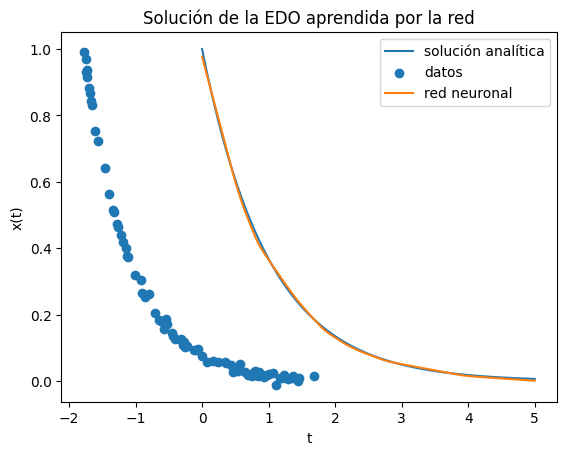

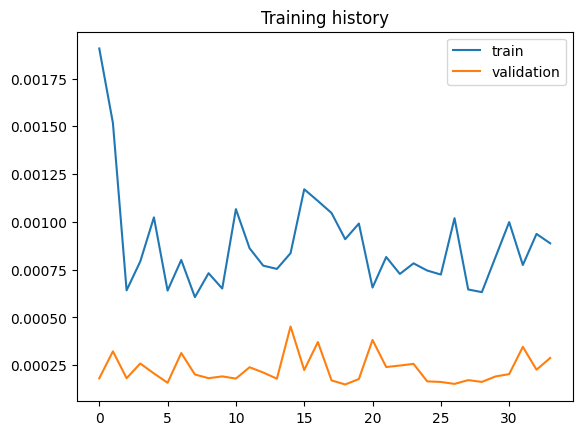

In [8]:
# ==========================================================
# SOLUCIÓN DE UNA EDO CON UNA RED NEURONAL (APRENDIENDO DATOS)
# dx/dt = -k x
# x(0)=1
# ==========================================================

np.random.seed(0)
tf.random.set_seed(0)

# ==========================================================
# 1. GENERAR DATOS NUMÉRICOS DE LA EDO
# ==========================================================

k = 1.0

t = np.linspace(0,5,400)

x = np.exp(-k*t)

# ruido experimental
x = x + np.random.normal(0,0.01,len(x))

X = t.reshape(-1,1)
y = x

# ==========================================================
# 2. TRAIN / VALIDATION / TEST
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=0)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,y_train,test_size=0.2,random_state=0)

# ==========================================================
# 3. NORMALIZACIÓN
# ==========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ==========================================================
# 4. MODELO CON HIPERPARÁMETROS
# ==========================================================

def build_model(hp):

    model = tf.keras.Sequential()

    for i in range(hp.Int("num_layers",1,3)):

        model.add(
            layers.Dense(
                units = hp.Int(f"units_{i}",16,128,step=16),
                activation = hp.Choice("activation",["relu","tanh"]),
                kernel_regularizer=tf.keras.regularizers.l2(
                    hp.Float("l2",1e-6,1e-2,sampling="log")
                )
            )
        )

        model.add(
            layers.Dropout(
                hp.Float("dropout",0.0,0.3,step=0.1)
            )
        )

    model.add(layers.Dense(1))

    lr = hp.Float("lr",1e-4,1e-2,sampling="log")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
        metrics=["mae"]
    )

    return model

# ==========================================================
# 5. HIPERPARAMETER SEARCH
# ==========================================================

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=20,
    directory="tuner_dir",
    project_name="edo_exponencial"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

tuner.search(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=150,
    callbacks=[early_stop],
    verbose=0
)

best_model = tuner.get_best_models(1)[0]

print("\nMejores hiperparámetros:")
print(tuner.get_best_hyperparameters(1)[0].values)

# ==========================================================
# 6. ENTRENAMIENTO FINAL
# ==========================================================

history = best_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=300,
    callbacks=[early_stop],
    verbose=0
)

# ==========================================================
# 7. EVALUACIÓN
# ==========================================================

loss,mae = best_model.evaluate(X_test,y_test,verbose=0)

print("\nMAE en test:",mae)

# ==========================================================
# 8. COMPARACIÓN CON SOLUCIÓN ANALÍTICA
# ==========================================================

t_line = np.linspace(0,5,300)

x_real = np.exp(-k*t_line)

x_nn = best_model.predict(
    scaler.transform(t_line.reshape(-1,1))
)

plt.figure()

plt.plot(t_line,x_real,label="solución analítica")
plt.scatter(X_test,y_test,label="datos")
plt.plot(t_line,x_nn,label="red neuronal")

plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.title("Solución de la EDO aprendida por la red")

plt.show()

# ==========================================================
# 9. HISTORIA DEL ENTRENAMIENTO
# ==========================================================

plt.figure()

plt.plot(history.history["loss"],label="train")
plt.plot(history.history["val_loss"],label="validation")

plt.legend()
plt.title("Training history")

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Mejores hiperparámetros:
{'num_layers': 3, 'units_0': 64, 'activation': 'relu', 'l2': 1.7797716021970918e-05, 'dropout': 0.1, 'lr': 0.0005236906227546035, 'units_1': 160, 'units_2': 96}

MAE test: 0.15253552794456482
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


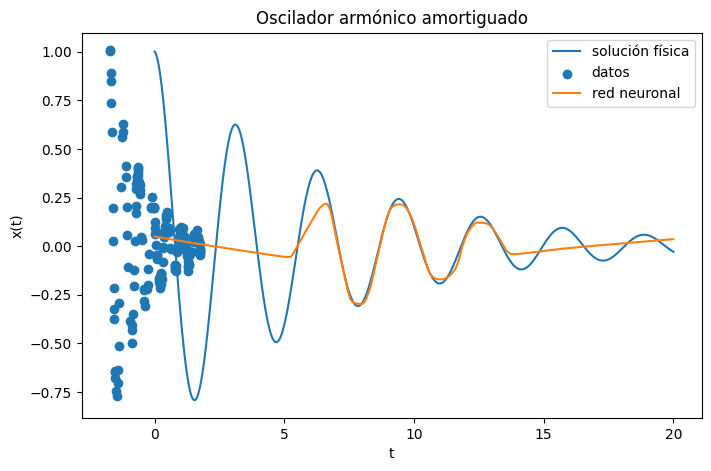

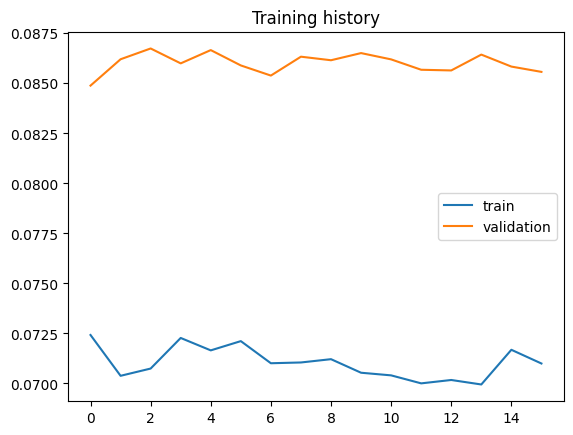

In [9]:
# ==========================================================
# OSCILADOR ARMÓNICO AMORTIGUADO (OAA) CON RED NEURONAL
# aprendizaje de la solución de la EDO a partir de datos
# ==========================================================

np.random.seed(0)
tf.random.set_seed(0)

# ==========================================================
# 1. GENERAR DATOS FÍSICOS
# ==========================================================

t = np.linspace(0,20,800)

A = 1.0
gamma = 0.3
w0 = 2.0

w = np.sqrt(w0**2 - (gamma**2)/4)

x = A*np.exp(-gamma*t/2)*np.cos(w*t)

# ruido experimental
x = x + np.random.normal(0,0.02,len(x))

X = t.reshape(-1,1)
y = x

# ==========================================================
# 2. TRAIN / VALIDATION / TEST
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=0)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,y_train,test_size=0.2,random_state=0)

# ==========================================================
# 3. NORMALIZACIÓN
# ==========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ==========================================================
# 4. MODELO CON HIPERPARÁMETROS
# ==========================================================

def build_model(hp):

    model = tf.keras.Sequential()

    for i in range(hp.Int("num_layers",1,3)):

        model.add(
            layers.Dense(
                units = hp.Int(f"units_{i}",32,256,step=32),
                activation = hp.Choice("activation",["tanh","relu"]),
                kernel_regularizer=tf.keras.regularizers.l2(
                    hp.Float("l2",1e-6,1e-2,sampling="log")
                )
            )
        )

        model.add(
            layers.Dropout(
                hp.Float("dropout",0.0,0.3,step=0.1)
            )
        )

    model.add(layers.Dense(1))

    lr = hp.Float("lr",1e-4,1e-2,sampling="log")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
        metrics=["mae"]
    )

    return model

# ==========================================================
# 5. HIPERPARAMETER SEARCH
# ==========================================================

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=20,
    directory="tuner_dir",
    project_name="oscilador_amortiguado"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

tuner.search(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=150,
    callbacks=[early_stop],
    verbose=0
)

best_model = tuner.get_best_models(1)[0]

print("\nMejores hiperparámetros:")
print(tuner.get_best_hyperparameters(1)[0].values)

# ==========================================================
# 6. ENTRENAMIENTO FINAL
# ==========================================================

history = best_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=300,
    callbacks=[early_stop],
    verbose=0
)

# ==========================================================
# 7. EVALUACIÓN
# ==========================================================

loss,mae = best_model.evaluate(X_test,y_test,verbose=0)

print("\nMAE test:",mae)

# ==========================================================
# 8. COMPARACIÓN CON SOLUCIÓN ANALÍTICA
# ==========================================================

t_line = np.linspace(0,20,600)

x_real = A*np.exp(-gamma*t_line/2)*np.cos(w*t_line)

x_nn = best_model.predict(
    scaler.transform(t_line.reshape(-1,1))
)

plt.figure(figsize=(8,5))

plt.plot(t_line,x_real,label="solución física")
plt.scatter(X_test,y_test,label="datos")
plt.plot(t_line,x_nn,label="red neuronal")

plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.title("Oscilador armónico amortiguado")

plt.show()

# ==========================================================
# 9. HISTORIA DE ENTRENAMIENTO
# ==========================================================

plt.figure()

plt.plot(history.history["loss"],label="train")
plt.plot(history.history["val_loss"],label="validation")

plt.legend()
plt.title("Training history")

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Mejores hiperparámetros:
{'num_layers': 3, 'units_0': 96, 'activation': 'relu', 'l2': 4.625403154015627e-06, 'dropout': 0.0, 'units_1': 96, 'lr': 0.0008276127298347325, 'units_2': 128, 'units_3': 160}
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


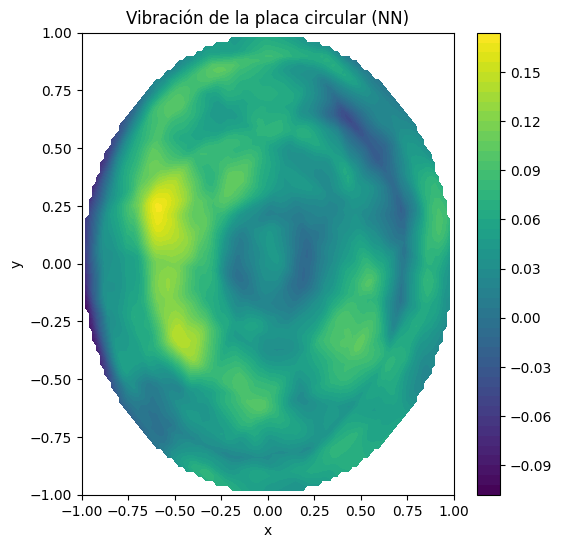

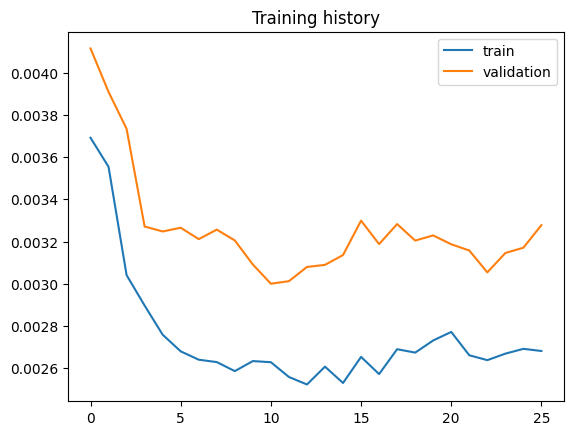

In [10]:
# ==========================================================
# VIBRACIÓN DE UNA PLACA CIRCULAR (EDP) CON RED NEURONAL
# aprendizaje de u(x,y,t)
# ==========================================================

np.random.seed(0)
tf.random.set_seed(0)

# ==========================================================
# 1. GENERAR DATOS DE LA PLACA CIRCULAR
# ==========================================================

R = 1.0
N = 8000

x = np.random.uniform(-R,R,N)
y = np.random.uniform(-R,R,N)
t = np.random.uniform(0,5,N)

r = np.sqrt(x**2 + y**2)

mask = r <= R

x = x[mask]
y = y[mask]
t = t[mask]

r = np.sqrt(x**2 + y**2)

# modo vibracional simple
omega = 3.0

u = np.sin(np.pi*r/R)*np.cos(omega*t)

# ruido experimental
u += np.random.normal(0,0.02,len(u))

X = np.vstack([x,y,t]).T
y = u

# ==========================================================
# 2. TRAIN / VALIDATION / TEST
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=0)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,y_train,test_size=0.2,random_state=0)

# ==========================================================
# 3. NORMALIZACIÓN
# ==========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ==========================================================
# 4. MODELO CON HIPERPARÁMETROS
# ==========================================================

def build_model(hp):

    model = tf.keras.Sequential()

    for i in range(hp.Int("num_layers",2,4)):

        model.add(
            layers.Dense(
                units = hp.Int(f"units_{i}",32,256,step=32),
                activation = hp.Choice("activation",["tanh","relu"]),
                kernel_regularizer=tf.keras.regularizers.l2(
                    hp.Float("l2",1e-6,1e-2,sampling="log")
                )
            )
        )

        model.add(
            layers.Dropout(
                hp.Float("dropout",0.0,0.3,step=0.1)
            )
        )

    model.add(layers.Dense(1))

    lr = hp.Float("lr",1e-4,1e-2,sampling="log")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
        metrics=["mae"]
    )

    return model

# ==========================================================
# 5. HIPERPARAMETER SEARCH
# ==========================================================

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=20,
    directory="tuner_dir",
    project_name="placa_circular"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

tuner.search(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=150,
    callbacks=[early_stop],
    verbose=0
)

best_model = tuner.get_best_models(1)[0]

print("Mejores hiperparámetros:")
print(tuner.get_best_hyperparameters(1)[0].values)

# ==========================================================
# 6. ENTRENAMIENTO FINAL
# ==========================================================

history = best_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=300,
    callbacks=[early_stop],
    verbose=0
)

# ==========================================================
# 7. VISUALIZACIÓN DEL CAMPO
# ==========================================================

grid = np.linspace(-R,R,100)

Xg,Yg = np.meshgrid(grid,grid)

r = np.sqrt(Xg**2 + Yg**2)

mask = r <= R

t0 = 0.5

points = np.vstack([Xg.ravel(),Yg.ravel(),np.full(Xg.size,t0)]).T

pred = best_model.predict(
    scaler.transform(points)
)

U = pred.reshape(Xg.shape)

U[~mask] = np.nan

plt.figure(figsize=(6,6))

plt.contourf(Xg,Yg,U,50)

plt.colorbar()

plt.title("Vibración de la placa circular (NN)")
plt.xlabel("x")
plt.ylabel("y")

plt.show()

# ==========================================================
# HISTORIA DE ENTRENAMIENTO
# ==========================================================

plt.figure()

plt.plot(history.history["loss"],label="train")
plt.plot(history.history["val_loss"],label="validation")

plt.legend()
plt.title("Training history")

plt.show()